# Amazon Big Sales Dataset 2026 - Python Analysis Notebook

**Created by Hieu Nguyen**

This notebook contains a full professional analysis workflow for `Amazon_Big_Sales_Dataset_2026.csv`: data loading, clean up, validation, feature engineering, KPI analysis, category analysis, product leaderboards, visualizations, and strategic recommendations.


## Methodology

The dataset includes product price, rating, and review count. It does **not** include actual units sold or realized revenue. For that reason, this notebook uses a transparent proxy called **Sales Potential**:

```text
Sales Potential = Price_USD x Review_Count
```

This is a directional demand/value signal, not actual revenue.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('default')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

DATA_PATH = Path('Amazon_Big_Sales_Dataset_2026.csv')
COLORS = {
    'Accessories': '#0f766e',
    'Audio': '#e85d45',
    'Electronics': '#d99a18',
    'Computers': '#3867d6',
}

def money(value):
    return f'${value:,.2f}'

def compact_money(value):
    if abs(value) >= 1_000_000:
        return f'${value / 1_000_000:,.1f}M'
    if abs(value) >= 1_000:
        return f'${value / 1_000:,.1f}K'
    return money(value)


## 1. Load Source Data


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df_raw):,}')
print(f'Columns: {len(df_raw.columns):,}')
display(df_raw.head())


Rows: 100
Columns: 6


,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count
0,AZ1001,Power Bank Model-39,Audio,591.53,4.10,4399
1,AZ1002,External SSD Model-20,Accessories,647.02,3.60,9779
2,AZ1003,Smart Watch Model-72,Accessories,419.88,4.70,9704
3,AZ1004,Graphics Card Model-97,Electronics,214.91,4.80,6305
4,AZ1005,Mechanical Keyboard Model-53,Computers,"1,002.45",4.10,8880


## 2. Data Clean Up and Validation

Clean up steps:
- Standardize column names and trim text fields
- Convert numeric fields to numeric data types
- Remove exact duplicate rows
- Check missing values, duplicate product IDs, invalid prices, invalid ratings, and invalid review counts


In [3]:
expected_columns = ['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Rating', 'Review_Count']

df = df_raw.copy()
df.columns = df.columns.str.strip()

missing_columns = sorted(set(expected_columns) - set(df.columns))
extra_columns = sorted(set(df.columns) - set(expected_columns))

text_columns = ['Product_ID', 'Product_Name', 'Category']
numeric_columns = ['Price_USD', 'Rating', 'Review_Count']

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

rows_before_dedup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
duplicate_rows_removed = rows_before_dedup - len(df)

missing_by_column = df[expected_columns].isna().sum()
duplicate_product_ids = df[df.duplicated('Product_ID', keep=False)].sort_values('Product_ID')

quality_checks = pd.DataFrame(
    [
        ('Missing expected columns', len(missing_columns)),
        ('Unexpected extra columns', len(extra_columns)),
        ('Exact duplicate rows removed', duplicate_rows_removed),
        ('Duplicate Product_ID values', int(duplicate_product_ids['Product_ID'].nunique())),
        ('Missing values across expected fields', int(missing_by_column.sum())),
        ('Nonpositive prices', int((df['Price_USD'] <= 0).sum())),
        ('Ratings outside 1 to 5', int(((df['Rating'] < 1) | (df['Rating'] > 5)).sum())),
        ('Negative review counts', int((df['Review_Count'] < 0).sum())),
    ],
    columns=['Check', 'Issue Count'],
)

display(quality_checks)
display(missing_by_column.to_frame('Missing Values'))

if missing_columns:
    print('Missing columns:', missing_columns)
if extra_columns:
    print('Extra columns:', extra_columns)


,Check,Issue Count
0,Missing expected columns,0
1,Unexpected extra columns,0
2,Exact duplicate rows removed,0
3,Duplicate Product_ID values,0
4,Missing values across expected fields,0
5,Nonpositive prices,0
6,Ratings outside 1 to 5,0
7,Negative review counts,0


,Missing Values
Product_ID,0
Product_Name,0
Category,0
Price_USD,0
Rating,0
Review_Count,0


## 3. Feature Engineering

New analytical fields:
- `Sales_Potential`: price multiplied by review count
- `Product_Family`: product family extracted from product name
- `Price_Tier`: quartile-based price segment
- `Rating_Band`: customer satisfaction segment
- `Review_Intensity`: quartile-based review-volume segment


In [4]:
df['Sales_Potential'] = df['Price_USD'] * df['Review_Count']
df['Product_Family'] = df['Product_Name'].str.extract(r'^(.+?) Model-', expand=False).fillna(df['Product_Name'])
df['Price_Tier'] = pd.qcut(df['Price_USD'], q=4, labels=['Value', 'Core', 'Premium', 'Ultra Premium'])
df['Rating_Band'] = pd.cut(
    df['Rating'],
    bins=[0, 3.75, 4.25, 4.75, 5.01],
    labels=['Needs Attention', 'Solid', 'Strong', 'Excellent'],
    include_lowest=True,
)
df['Review_Intensity'] = pd.qcut(df['Review_Count'], q=4, labels=['Low', 'Moderate', 'High', 'Very High'])

display(df.head())


,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count,Sales_Potential,Product_Family,Price_Tier,Rating_Band,Review_Intensity
0,AZ1001,Power Bank Model-39,Audio,591.53,4.10,4399,"2,602,140.47",Power Bank,Core,Solid,Moderate
1,AZ1002,External SSD Model-20,Accessories,647.02,3.60,9779,"6,327,208.58",External SSD,Core,Needs Attention,Very High
2,AZ1003,Smart Watch Model-72,Accessories,419.88,4.70,9704,"4,074,515.52",Smart Watch,Core,Strong,Very High
3,AZ1004,Graphics Card Model-97,Electronics,214.91,4.80,6305,"1,355,007.55",Graphics Card,Value,Excellent,High
4,AZ1005,Mechanical Keyboard Model-53,Computers,"1,002.45",4.10,8880,"8,901,756.00",Mechanical Keyboard,Premium,Solid,Very High


## 4. Portfolio KPI Summary


In [5]:
total_categories = df['Category'].nunique()
avg_price = df['Price_USD'].mean()
min_price = df['Price_USD'].min()
max_price = df['Price_USD'].max()
avg_rating = df['Rating'].mean()
total_reviews = df['Review_Count'].sum()
avg_reviews = df['Review_Count'].mean()
total_sales_potential = df['Sales_Potential'].sum()

portfolio_kpis = pd.DataFrame(
    [
        ('Total Products', f'{len(df):,}'),
        ('Categories', f'{total_categories:,}'),
        ('Average Price', money(avg_price)),
        ('Price Range', f'{money(min_price)} to {money(max_price)}'),
        ('Average Rating', f'{avg_rating:.2f}'),
        ('Total Reviews', f'{total_reviews:,}'),
        ('Average Reviews per Product', f'{avg_reviews:,.0f}'),
        ('Estimated Sales Potential', compact_money(total_sales_potential)),
    ],
    columns=['Metric', 'Value'],
)

display(portfolio_kpis)


,Metric,Value
0,Total Products,100
1,Categories,4
2,Average Price,$738.97
3,Price Range,"$23.23 to $1,476.80"
4,Average Rating,4.29
5,Total Reviews,"483,421"
6,Average Reviews per Product,"4,834"
7,Estimated Sales Potential,$349.0M


## 5. Category Performance

This section compares each category by product count, average price, average rating, total reviews, and sales-potential contribution.


In [6]:
category_summary = (
    df.groupby('Category')
    .agg(
        Products=('Product_ID', 'count'),
        Avg_Price=('Price_USD', 'mean'),
        Min_Price=('Price_USD', 'min'),
        Max_Price=('Price_USD', 'max'),
        Avg_Rating=('Rating', 'mean'),
        Total_Reviews=('Review_Count', 'sum'),
        Avg_Reviews=('Review_Count', 'mean'),
        Sales_Potential=('Sales_Potential', 'sum'),
    )
    .sort_values('Sales_Potential', ascending=False)
)

category_summary['Review_Share'] = category_summary['Total_Reviews'] / category_summary['Total_Reviews'].sum()
category_summary['Sales_Potential_Share'] = category_summary['Sales_Potential'] / category_summary['Sales_Potential'].sum()

display(
    category_summary.style.format(
        {
            'Avg_Price': '${:,.2f}',
            'Min_Price': '${:,.2f}',
            'Max_Price': '${:,.2f}',
            'Avg_Rating': '{:.2f}',
            'Total_Reviews': '{:,.0f}',
            'Avg_Reviews': '{:,.0f}',
            'Sales_Potential': '${:,.0f}',
            'Review_Share': '{:.1%}',
            'Sales_Potential_Share': '{:.1%}',
        }
    )
)


,Products,Avg_Price,Min_Price,Max_Price,Avg_Rating,Total_Reviews,Avg_Reviews,Sales_Potential,Review_Share,Sales_Potential_Share
Category,,,,,,,,,,
Computers,21,$796.35,$188.85,"$1,392.17",4.21,"114,191","5,438","$97,892,173",23.6%,28.1%
Accessories,29,$826.43,$144.71,"$1,476.80",4.35,"121,536","4,191","$92,107,906",25.1%,26.4%
Electronics,23,$620.84,$66.98,"$1,308.24",4.27,"131,383","5,712","$81,653,445",27.2%,23.4%
Audio,27,$701.05,$23.23,"$1,386.96",4.30,"116,311","4,308","$77,319,236",24.1%,22.2%


## 6. Product Leaderboards


In [7]:
leaderboard_columns = ['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Rating', 'Review_Count', 'Sales_Potential']

top_by_reviews = df.nlargest(10, 'Review_Count')[leaderboard_columns]
top_by_rating = df.sort_values(['Rating', 'Review_Count'], ascending=[False, False]).head(10)[leaderboard_columns]
top_by_sales_potential = df.nlargest(10, 'Sales_Potential')[leaderboard_columns]

def display_leaderboard(title, data):
    display(Markdown(f'### {title}'))
    display(
        data.style.format(
            {
                'Price_USD': '${:,.2f}',
                'Rating': '{:.1f}',
                'Review_Count': '{:,.0f}',
                'Sales_Potential': '${:,.0f}',
            }
        )
    )

display_leaderboard('Top 10 Products by Review Count', top_by_reviews)
display_leaderboard('Top 10 Products by Rating, then Reviews', top_by_rating)
display_leaderboard('Top 10 Products by Sales Potential', top_by_sales_potential)


### Top 10 Products by Review Count

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count,Sales_Potential
34,AZ1035,USB-C Hub Model-10,Accessories,$784.80,4.8,"9,953","$7,811,114"
1,AZ1002,External SSD Model-20,Accessories,$647.02,3.6,"9,779","$6,327,209"
2,AZ1003,Smart Watch Model-72,Accessories,$419.88,4.7,"9,704","$4,074,516"
83,AZ1084,Webcam Pro Model-18,Electronics,$149.62,4.6,"9,704","$1,451,912"
21,AZ1022,Gaming Laptop Model-26,Electronics,$506.59,4.9,"9,645","$4,886,061"
84,AZ1085,External SSD Model-77,Audio,$456.31,4.6,"8,947","$4,082,606"
4,AZ1005,Mechanical Keyboard Model-53,Computers,"$1,002.45",4.1,"8,880","$8,901,756"
92,AZ1093,Tablet Model-24,Computers,$431.52,5.0,"8,832","$3,811,185"
46,AZ1047,Mechanical Keyboard Model-60,Electronics,$641.42,4.6,"8,722","$5,594,465"
22,AZ1023,Mechanical Keyboard Model-30,Electronics,$610.52,3.7,"8,720","$5,323,734"


### Top 10 Products by Rating, then Reviews

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count,Sales_Potential
92,AZ1093,Tablet Model-24,Computers,$431.52,5.0,"8,832","$3,811,185"
32,AZ1033,Tablet Model-60,Audio,"$1,179.84",5.0,"4,108","$4,846,783"
38,AZ1039,Mechanical Keyboard Model-54,Accessories,"$1,051.98",5.0,"3,193","$3,358,972"
26,AZ1027,Tablet Model-69,Audio,$812.22,5.0,"1,609","$1,306,862"
21,AZ1022,Gaming Laptop Model-26,Electronics,$506.59,4.9,"9,645","$4,886,061"
45,AZ1046,Smart Watch Model-75,Accessories,$375.18,4.9,"8,672","$3,253,561"
67,AZ1068,USB-C Hub Model-89,Audio,"$1,016.97",4.9,"8,651","$8,797,807"
13,AZ1014,Power Bank Model-58,Audio,$321.92,4.9,"7,059","$2,272,433"
9,AZ1010,Smart Watch Model-27,Audio,$35.02,4.9,"5,453","$190,964"
78,AZ1079,External SSD Model-96,Electronics,$383.39,4.9,"4,381","$1,679,632"


### Top 10 Products by Sales Potential

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count,Sales_Potential
75,AZ1076,Mechanical Keyboard Model-87,Computers,"$1,296.17",4.1,"7,984","$10,348,621"
31,AZ1032,Bluetooth Headphones Model-32,Computers,"$1,143.05",4.0,"8,112","$9,272,422"
4,AZ1005,Mechanical Keyboard Model-53,Computers,"$1,002.45",4.1,"8,880","$8,901,756"
76,AZ1077,VR Headset Model-24,Audio,"$1,233.49",4.1,"7,205","$8,887,295"
67,AZ1068,USB-C Hub Model-89,Audio,"$1,016.97",4.9,"8,651","$8,797,807"
50,AZ1051,Graphics Card Model-39,Computers,"$1,392.17",4.8,"6,300","$8,770,671"
15,AZ1016,Tablet Model-67,Electronics,"$1,130.81",4.5,"7,707","$8,715,153"
24,AZ1025,External SSD Model-31,Electronics,"$1,308.24",4.3,"6,475","$8,470,854"
86,AZ1087,Smart Watch Model-14,Accessories,"$1,112.87",4.0,"7,517","$8,365,444"
98,AZ1099,External SSD Model-31,Computers,"$1,040.16",4.4,"7,714","$8,023,794"


## 7. Product Family Analysis

Product family analysis helps identify which product types carry the strongest review momentum and sales potential regardless of the category label.


In [8]:
family_summary = (
    df.groupby('Product_Family')
    .agg(
        Products=('Product_ID', 'count'),
        Avg_Price=('Price_USD', 'mean'),
        Avg_Rating=('Rating', 'mean'),
        Total_Reviews=('Review_Count', 'sum'),
        Sales_Potential=('Sales_Potential', 'sum'),
    )
    .sort_values('Sales_Potential', ascending=False)
)

display(
    family_summary.style.format(
        {
            'Avg_Price': '${:,.2f}',
            'Avg_Rating': '{:.2f}',
            'Total_Reviews': '{:,.0f}',
            'Sales_Potential': '${:,.0f}',
        }
    )
)


,Products,Avg_Price,Avg_Rating,Total_Reviews,Sales_Potential
Product_Family,,,,,
Mechanical Keyboard,13,$829.97,4.28,"72,102","$60,225,641"
External SSD,17,$758.31,4.18,"71,663","$58,789,776"
USB-C Hub,9,$594.09,4.44,"45,529","$27,730,035"
4K Monitor,7,$831.51,4.24,"27,385","$26,348,560"
Gaming Laptop,7,$928.62,4.20,"29,723","$25,196,970"
VR Headset,5,$774.24,4.06,"31,649","$23,876,822"
Smart Watch,7,$480.75,4.49,"41,436","$23,492,943"
Tablet,6,$958.64,4.63,"24,299","$21,007,075"
Wireless Mouse,8,$699.36,4.36,"33,990","$20,735,369"


## 8. Price Tier and Rating Band Analysis


In [9]:
price_tier_summary = (
    df.groupby('Price_Tier', observed=True)
    .agg(
        Products=('Product_ID', 'count'),
        Avg_Price=('Price_USD', 'mean'),
        Avg_Rating=('Rating', 'mean'),
        Total_Reviews=('Review_Count', 'sum'),
        Sales_Potential=('Sales_Potential', 'sum'),
    )
)

rating_band_summary = (
    df.groupby('Rating_Band', observed=True)
    .agg(
        Products=('Product_ID', 'count'),
        Avg_Price=('Price_USD', 'mean'),
        Avg_Rating=('Rating', 'mean'),
        Total_Reviews=('Review_Count', 'sum'),
        Sales_Potential=('Sales_Potential', 'sum'),
    )
)

display(Markdown('### Price Tier Summary'))
display(price_tier_summary.style.format({'Avg_Price': '${:,.2f}', 'Avg_Rating': '{:.2f}', 'Total_Reviews': '{:,.0f}', 'Sales_Potential': '${:,.0f}'}))

display(Markdown('### Rating Band Summary'))
display(rating_band_summary.style.format({'Avg_Price': '${:,.2f}', 'Avg_Rating': '{:.2f}', 'Total_Reviews': '{:,.0f}', 'Sales_Potential': '${:,.0f}'}))


### Price Tier Summary

,Products,Avg_Price,Avg_Rating,Total_Reviews,Sales_Potential
Price_Tier,,,,,
Value,25,$202.19,4.27,"117,299","$24,771,390"
Core,25,$556.92,4.33,"128,362","$70,859,822"
Premium,25,$930.93,4.28,"133,388","$123,220,423"
Ultra Premium,25,"$1,265.86",4.27,"104,372","$130,121,125"


### Rating Band Summary

,Products,Avg_Price,Avg_Rating,Total_Reviews,Sales_Potential
Rating_Band,,,,,
Needs Attention,14,$581.05,3.62,"69,401","$42,942,536"
Solid,34,$823.03,4.01,"159,396","$134,526,981"
Strong,30,$775.30,4.49,"142,547","$98,701,759"
Excellent,22,$660.03,4.88,"112,077","$72,801,484"


## 9. Visual Analysis - Category Performance


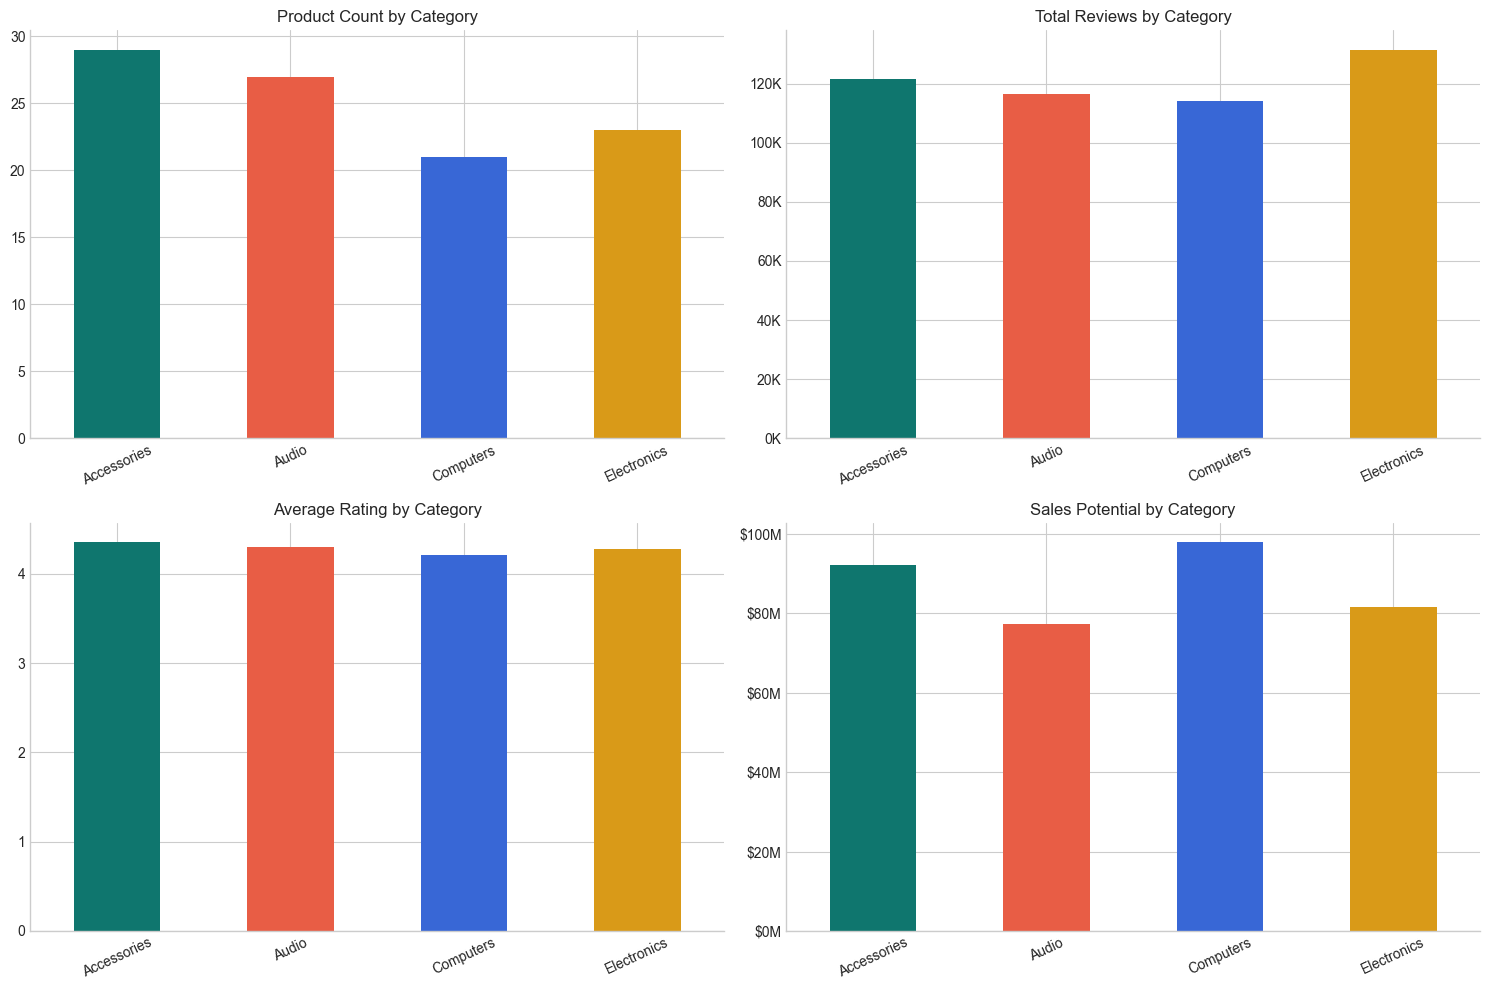

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_data = category_summary.sort_index()
bar_colors = [COLORS.get(category, '#666666') for category in plot_data.index]

plot_data['Products'].plot(kind='bar', ax=axes[0, 0], color=bar_colors, title='Product Count by Category')
plot_data['Total_Reviews'].plot(kind='bar', ax=axes[0, 1], color=bar_colors, title='Total Reviews by Category')
plot_data['Avg_Rating'].plot(kind='bar', ax=axes[1, 0], color=bar_colors, title='Average Rating by Category')
plot_data['Sales_Potential'].plot(kind='bar', ax=axes[1, 1], color=bar_colors, title='Sales Potential by Category')

for ax in axes.flat:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)

axes[0, 1].yaxis.set_major_formatter(lambda value, _: f'{value / 1_000:.0f}K')
axes[1, 1].yaxis.set_major_formatter(lambda value, _: f'${value / 1_000_000:.0f}M')

plt.tight_layout()
plt.show()


## 10. Visual Analysis - Review Share Donut


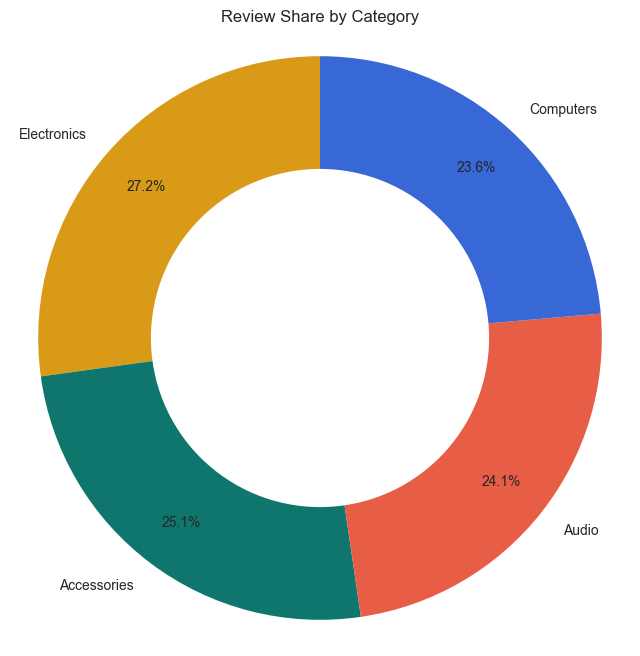

In [11]:
review_share = category_summary.sort_values('Total_Reviews', ascending=False)['Total_Reviews']
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    review_share,
    labels=review_share.index,
    colors=[COLORS.get(category, '#666666') for category in review_share.index],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
)
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Review Share by Category')
ax.axis('equal')
plt.show()


## 11. Visual Analysis - Price, Rating, and Review Momentum

Bubble size represents review count. The chart helps separate premium high-momentum products from lower-price high-review products.


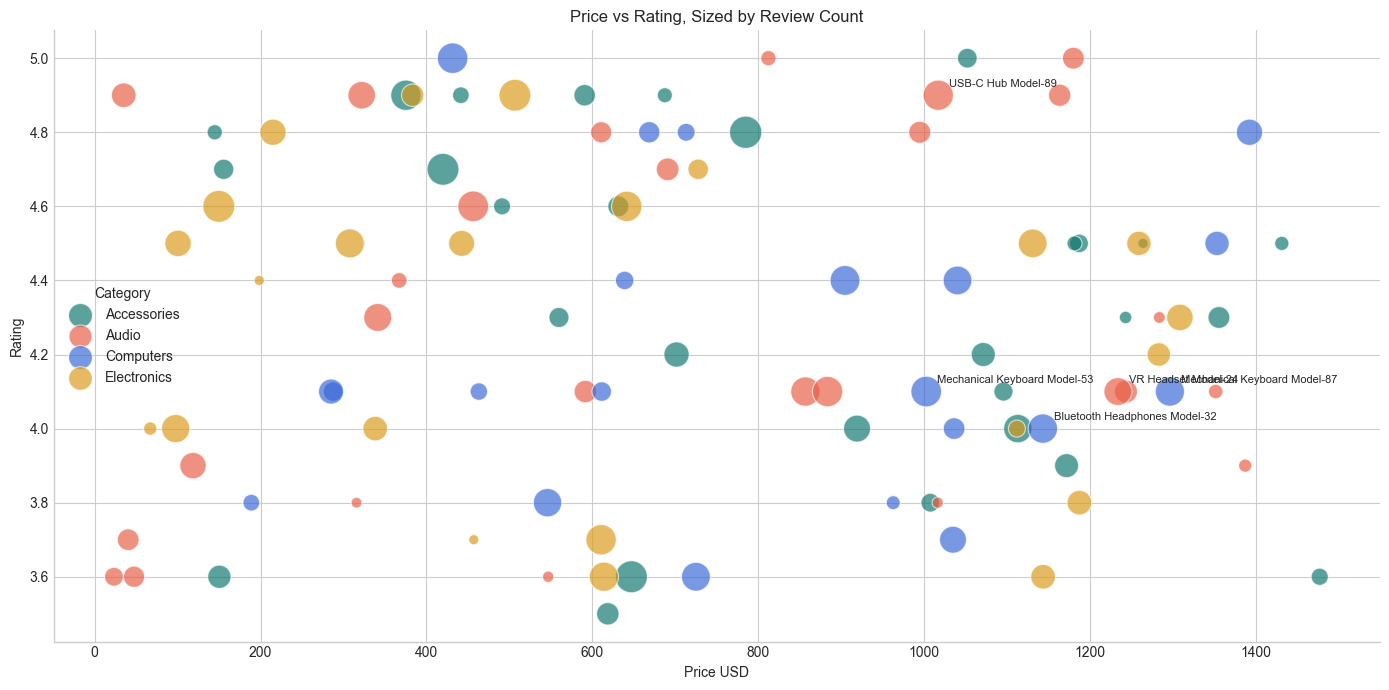

In [12]:
fig, ax = plt.subplots(figsize=(14, 7))

for category, subset in df.groupby('Category'):
    ax.scatter(
        subset['Price_USD'],
        subset['Rating'],
        s=40 + (subset['Review_Count'] / df['Review_Count'].max()) * 500,
        alpha=0.68,
        label=category,
        color=COLORS.get(category, '#666666'),
        edgecolor='white',
        linewidth=0.8,
    )

top_points = df.nlargest(5, 'Sales_Potential')
for _, row in top_points.iterrows():
    ax.annotate(
        row['Product_Name'],
        (row['Price_USD'], row['Rating']),
        xytext=(8, 6),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_title('Price vs Rating, Sized by Review Count')
ax.set_xlabel('Price USD')
ax.set_ylabel('Rating')
ax.legend(title='Category')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 12. Visual Analysis - Distributions


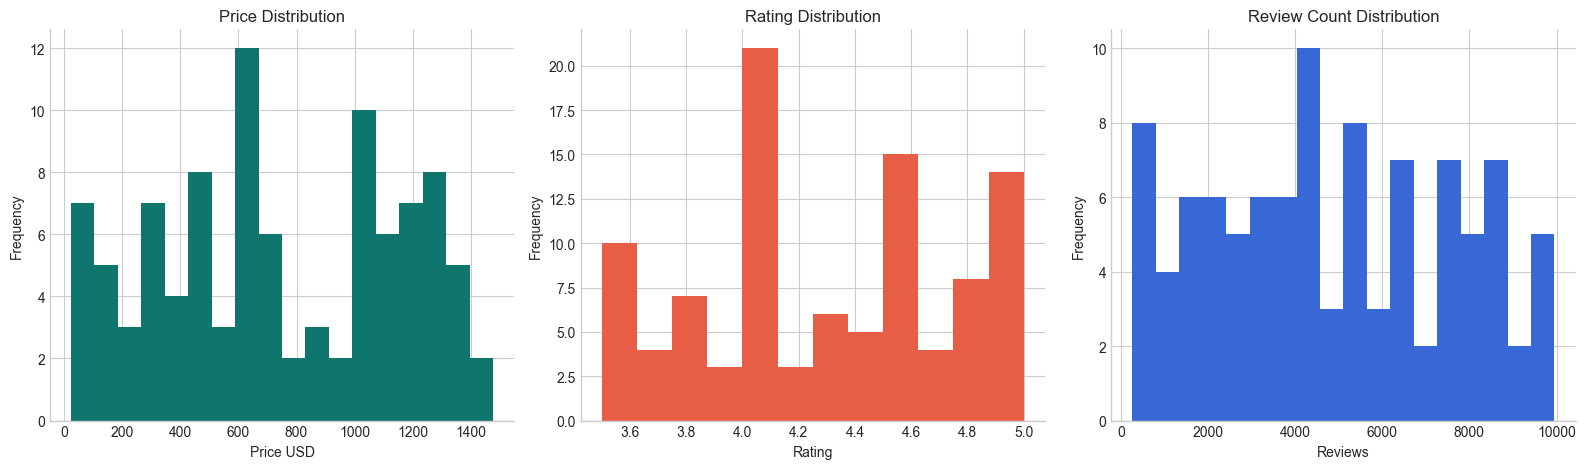

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

df['Price_USD'].plot(kind='hist', bins=18, ax=axes[0], color='#0f766e', title='Price Distribution')
df['Rating'].plot(kind='hist', bins=12, ax=axes[1], color='#e85d45', title='Rating Distribution')
df['Review_Count'].plot(kind='hist', bins=18, ax=axes[2], color='#3867d6', title='Review Count Distribution')

axes[0].set_xlabel('Price USD')
axes[1].set_xlabel('Rating')
axes[2].set_xlabel('Reviews')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


## 13. Correlation Analysis


,Price_USD,Rating,Review_Count,Sales_Potential
Price_USD,1.00,-0.02,-0.07,0.59
Rating,-0.02,1.00,0.08,-0.01
Review_Count,-0.07,0.08,1.00,0.66
Sales_Potential,0.59,-0.01,0.66,1.00


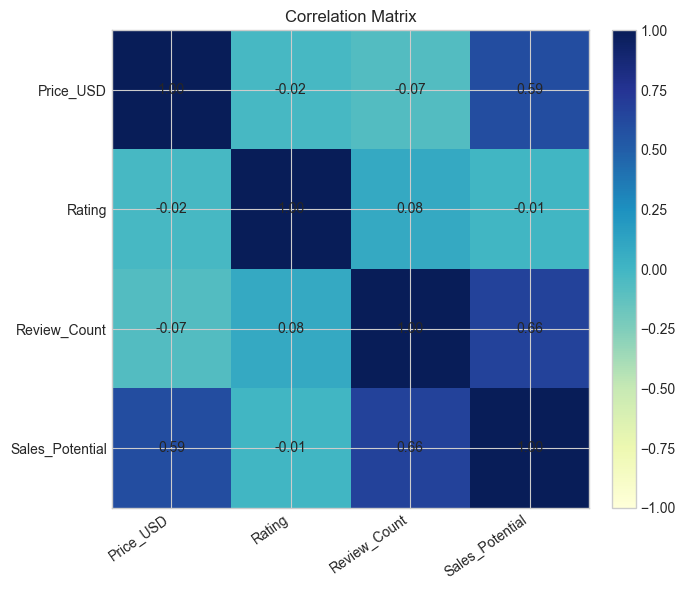

In [14]:
correlation_fields = ['Price_USD', 'Rating', 'Review_Count', 'Sales_Potential']
correlation_matrix = df[correlation_fields].corr()
display(correlation_matrix.style.background_gradient(cmap='YlGnBu').format('{:.2f}'))

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation_matrix, cmap='YlGnBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_fields)), correlation_fields, rotation=35, ha='right')
ax.set_yticks(range(len(correlation_fields)), correlation_fields)

for row_index in range(len(correlation_fields)):
    for column_index in range(len(correlation_fields)):
        ax.text(column_index, row_index, f'{correlation_matrix.iloc[row_index, column_index]:.2f}', ha='center', va='center')

ax.set_title('Correlation Matrix')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 14. Executive Findings and Recommendations


In [15]:
assortment_leader = category_summary.sort_values('Products', ascending=False).iloc[0]
review_leader = category_summary.sort_values('Total_Reviews', ascending=False).iloc[0]
rating_leader = category_summary.sort_values('Avg_Rating', ascending=False).iloc[0]
potential_leader = category_summary.sort_values('Sales_Potential', ascending=False).iloc[0]
top_review_product = df.sort_values('Review_Count', ascending=False).iloc[0]
top_potential_product = df.sort_values('Sales_Potential', ascending=False).iloc[0]

display(Markdown(f'''
### Executive Findings

1. **{potential_leader.name} leads sales potential** with {compact_money(potential_leader['Sales_Potential'])}, even though it has {int(potential_leader['Products'])} products.
2. **{assortment_leader.name} has the broadest assortment** with {int(assortment_leader['Products'])} products.
3. **{review_leader.name} leads customer attention** with {int(review_leader['Total_Reviews']):,} total reviews.
4. **{rating_leader.name} has the strongest average rating** at {rating_leader['Avg_Rating']:.2f}.
5. **{top_review_product['Product_Name']}** is the top review-volume product with {int(top_review_product['Review_Count']):,} reviews.
6. **{top_potential_product['Product_Name']}** is the top sales-potential product at {compact_money(top_potential_product['Sales_Potential'])}.

### Recommendations

- Prioritize high-sales-potential SKUs for inventory protection, pricing review, and promotional support.
- Use high-rating categories and products as bundle/cross-sell candidates.
- Investigate high-review but lower-rating products for quality, positioning, or review-management improvement.
- Segment pricing decisions by product family and customer response instead of using one broad pricing rule.
- Treat Sales Potential as a directional opportunity signal, not as actual revenue.
'''))



### Executive Findings

1. **Computers leads sales potential** with $97.9M, even though it has 21 products.
2. **Accessories has the broadest assortment** with 29 products.
3. **Electronics leads customer attention** with 131,383 total reviews.
4. **Accessories has the strongest average rating** at 4.35.
5. **USB-C Hub Model-10** is the top review-volume product with 9,953 reviews.
6. **Mechanical Keyboard Model-87** is the top sales-potential product at $10.3M.

### Recommendations

- Prioritize high-sales-potential SKUs for inventory protection, pricing review, and promotional support.
- Use high-rating categories and products as bundle/cross-sell candidates.
- Investigate high-review but lower-rating products for quality, positioning, or review-management improvement.
- Segment pricing decisions by product family and customer response instead of using one broad pricing rule.
- Treat Sales Potential as a directional opportunity signal, not as actual revenue.


## 15. Export Cleaned Analysis Dataset

Optional cell: export the cleaned and feature-enriched dataset for reuse in dashboards, reports, or machine learning workflows.


In [16]:
OUTPUT_PATH = Path('Amazon_Big_Sales_Dataset_2026_Cleaned.csv')
df.to_csv(OUTPUT_PATH, index=False)
print(f'Cleaned dataset exported to: {OUTPUT_PATH.resolve()}')


Cleaned dataset exported to: C:\Users\hieum\Desktop\Repo\Amazon_Tech_Trends_Sales_Insight_2026\Amazon_Tech_Trends_Sales_Insight_2026\Amazon_Big_Sales_Dataset_2026_Cleaned.csv
